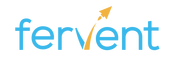
# Estimating Correlation - Applied
In this walkthrough, you'll explore how we can calculate the correlation of securities on Python.

Recall that correlation is estimated as...

$$\rho_{j,k} = \frac{\sigma_{j,k}}{\sigma_j \sigma_k}$$

Where:  
$\rho_{j,k} = $ Correlation between stocks $j$ and $k$  
$\sigma_{j,k} = $ Covariance between stocks $j$ and $k$  
$\sigma_j = $ Standard deviation (total risk) of stock $j$

In [1]:
# Import packages
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/15stocks_price.csv')  # stock price data

# Convert dates to timestamps and set date column as the index
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'])
df.set_index('date_gsheets', inplace=True)

# Calculate returns for all securities
returns_df = df.pct_change(1)

# Drop / delete missing observations
returns_df.dropna(inplace=True)

In [3]:
returns_df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA,MA,AMZN,MSFT,UN,V
date_gsheets,,,,,,,,,,,,,,,
2012-01-04 16:00:00,0.005277,-0.006273,0.113372,-0.011329,0.014096,-0.004079,-0.013088,-0.010277,0.010893,-0.013177,-0.032845,-0.008490,0.023534,-0.013459,-0.017864
2012-01-05 16:00:00,0.011175,-0.004591,-0.013925,0.001693,0.016731,-0.004743,-0.006886,-0.004857,-0.000539,-0.021292,-0.010946,0.000563,0.010219,0.001161,0.007513
2012-01-06 16:00:00,0.010382,-0.006342,0.088261,-0.007019,0.010380,-0.011481,-0.015665,-0.007068,0.005391,-0.007743,-0.026958,0.028152,0.015535,-0.035373,-0.011774
2012-01-09 16:00:00,-0.001492,0.000000,0.137875,-0.001309,-0.004009,-0.005204,0.001044,0.003051,0.011260,0.012635,0.008457,-0.022178,-0.013163,0.013526,-0.007943
2012-01-10 16:00:00,0.003485,0.005802,-0.024234,0.014812,-0.003019,-0.001542,0.005212,-0.002366,-0.007423,0.013578,0.008676,0.004368,0.003605,0.005635,-0.001201


In [4]:
# Estimate the covariance between Apple and Coca Cola
cov_aapl_ko = np.cov(returns_df['AAPL'], returns_df['KO'])[0][1]

In [5]:
# Estimate the standard deviation of Apple and Coca Cola
std_aapl = returns_df['AAPL'].std()
std_ko = returns_df['KO'].std()

In [6]:
# Estimate the correlation between Apple and Coca Cola
corr_aapl_ko = cov_aapl_ko / (std_aapl * std_ko)

In [7]:
corr_aapl_ko

0.20541727242368507

In [8]:
# Estimate the correlations across all securities
corr_matrix = returns_df.corr()

In [9]:
corr_matrix.round(2)

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA,MA,AMZN,MSFT,UN,V
AAPL,1.00,0.21,0.12,0.31,0.27,0.26,0.17,0.17,0.26,0.20,0.35,0.26,0.33,0.25,0.30
KO,0.21,1.00,0.09,0.47,0.37,0.32,0.37,0.31,0.35,0.14,0.36,0.23,0.32,0.41,0.33
NFLX,0.12,0.09,1.00,0.19,0.15,0.12,0.04,0.10,0.16,0.23,0.25,0.30,0.21,0.15,0.22
BRK.B,0.31,0.47,0.19,1.00,0.54,0.48,0.42,0.33,0.55,0.22,0.53,0.33,0.43,0.42,0.50
DIS,0.27,0.37,0.15,0.54,1.00,0.34,0.34,0.27,0.43,0.23,0.43,0.31,0.35,0.33,0.41
IBM,0.26,0.32,0.12,0.48,0.34,1.00,0.30,0.23,0.43,0.18,0.38,0.23,0.39,0.30,0.36
VZ,0.17,0.37,0.04,0.42,0.34,0.30,1.00,0.29,0.37,0.11,0.28,0.17,0.29,0.31,0.27
WMT,0.17,0.31,0.10,0.33,0.27,0.23,0.29,1.00,0.24,0.11,0.25,0.14,0.22,0.23,0.25
GE,0.26,0.35,0.16,0.55,0.43,0.43,0.37,0.24,1.00,0.19,0.40,0.26,0.34,0.33,0.38
TSLA,0.20,0.14,0.23,0.22,0.23,0.18,0.11,0.11,0.19,1.00,0.27,0.26,0.21,0.18,0.23
